In [1]:
print("___")

___


## Machine Learning for Hyperspectral Image Analysis _ Part 2
### Sagar Lekhak, Phd Student, Year II.
### Chester F. Carlson Center for Imaging Science, Rochester Institute of Technology.

### Problem 1: Classification of Hyperspectral Image

#### 1.a. Perform all necessary exploratory data analysis (EDA) on the given dataset. Explain what are the important aspects of this dataset that needs to be explored before delving into solving the problem.

In [9]:
# Importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.io import loadmat


In [29]:
# Loading the data
# We can also use other kinds of libraries to load the data such as h5py or mat73, but we will use scipy to load the data.
# loadmat might not work if the data is stored in latest versions of matlab. In that case, we can use h5py or mat73 to load the data. In this case, we will use loadmat to load the data.
pavia_data = loadmat('paviaU.mat')
pavia_gt = loadmat('paviaU_gt.mat')

In [15]:
#.mat files are stored in such a way that the variable names are stored as keys in the dictionary. The keys in the dictionary are the variable names and the values are the data stored in the variable. We need to extract the data from the dictionary and store it in a variable.
#Our concern is the data stored in the variable 'paviaU'. We will extract the data from the dictionary and store it in a variable.
print(pavia_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'paviaU'])


In [16]:
paviaU = pavia_data['paviaU']  # Extracting the data from the dictionary and storing it in a variable.

In [18]:
paviaU.shape

(610, 340, 103)

In [19]:
paviaU.dtype  #The data type is unsigned integer type of 16 bits. This means that the data is stored in the form of 16 bit unsigned integers.

dtype('<u2')

In [20]:
print(type(paviaU))  #Checking if the data is stored in the form of a numpy array or not.

<class 'numpy.ndarray'>


In [23]:
# It means the data is stored in the form of a numpy array.
# Now we can visualize the data and do necessary exploratory data analysis as required.
print(paviaU[:,:,0])  #Printing the first band of the data.

[[ 647  604  621 ...  524  528  711]
 [ 705  891  547 ... 1149  917 1037]
 [1084  335 1042 ...  799  226  828]
 ...
 [ 733  785  826 ...  704  376 1146]
 [ 785  856 1088 ...  717  548  768]
 [1006  970 1218 ...  593  593  889]]


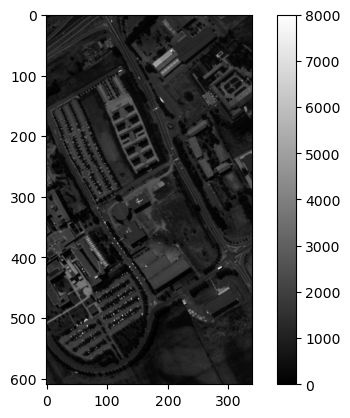

In [28]:
#It looks like the data is in digital counts. Let's plot the first band of the data to see what it looks like.
plt.imshow(paviaU[:,:,59], cmap = 'gray')  #Plotting the first band of the data.
plt.colorbar()
plt.show()

(array([5.6800e+02, 8.4900e+02, 1.7130e+03, 3.1070e+03, 5.5590e+03,
        8.9030e+03, 1.2682e+04, 1.6383e+04, 1.9071e+04, 2.0320e+04,
        2.0084e+04, 1.8431e+04, 1.5970e+04, 1.3334e+04, 1.0804e+04,
        8.5690e+03, 6.9750e+03, 5.1980e+03, 4.0730e+03, 2.9910e+03,
        2.1120e+03, 1.5890e+03, 1.2150e+03, 9.0700e+02, 6.9300e+02,
        6.3800e+02, 5.5100e+02, 4.9400e+02, 4.5600e+02, 3.3000e+02,
        3.3000e+02, 2.3700e+02, 2.2500e+02, 1.8200e+02, 1.6400e+02,
        1.5900e+02, 1.6500e+02, 1.2100e+02, 1.2600e+02, 1.2300e+02,
        1.2800e+02, 1.3000e+02, 1.3400e+02, 1.1100e+02, 9.8000e+01,
        1.0200e+02, 9.1000e+01, 7.1000e+01, 4.7000e+01, 2.6000e+01,
        2.0000e+01, 9.0000e+00, 9.0000e+00, 2.0000e+00, 3.0000e+00,
        1.0000e+00, 0.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 2.00

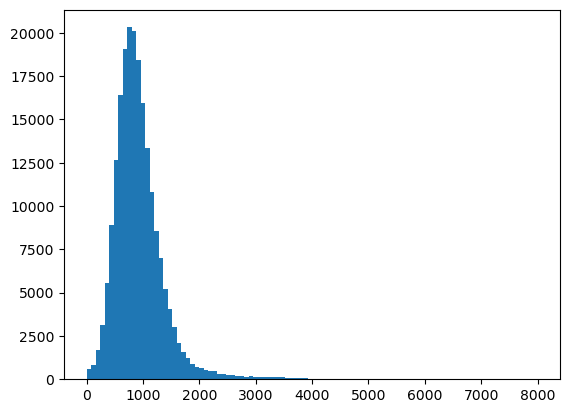

In [31]:
#The data looks like a grayscale image. Let's plot the histogram of the first band of the data to see what it looks like.
plt.hist(paviaU[:,:,0].flatten(), bins = 100)  #Plotting the histogram of the first band of the data.

In [36]:
print(paviaU[:,:,0].min(), paviaU[:,:,0].max())  #Printing the minimum and maximum values of the first band of the data.
print(paviaU[:,:,0].mean(), paviaU[:,:,0].std())  #Printing the mean and standard deviation of the first band of the data.
print(paviaU[0,0,:]) #print the first pixel of the data.


0 8000
925.3249951783993 444.4264280637997
[ 647  499  464  371  291  319  365  322  296  305  277  219  219  222
  201  162  157  183  204  194  198  216  249  284  294  322  338  342
  336  342  362  365  348  341  324  316  293  274  251  244  263  248
  236  254  255  240  223  203  202  191  185  200  203  181  168  174
  185  187  165  151  144  140  149  169  192  227  287  376  493  633
  763  913 1149 1442 1759 2102 2425 2689 2895 3058 3196 3252 3195 3297
 3542 3550 3537 3545 3514 3477 3468 3433 3408 3420 3416 3335 3256 3226
 3205 3210 3221 3238 3250]


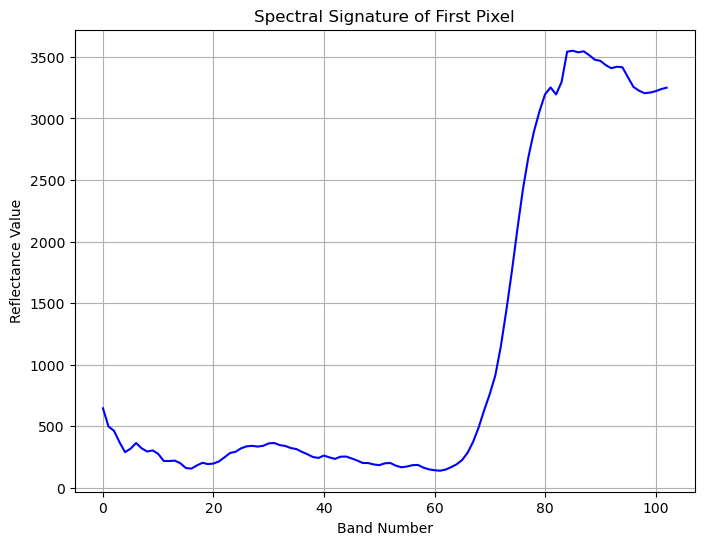

In [50]:
# Extract the first pixel (all bands)
first_pixel = paviaU[0, 0, :]

# Plot the spectral signature
plt.figure(figsize=(8, 6))
plt.plot(first_pixel, linestyle='-', color='b')
plt.xlabel('Band Number')
plt.ylabel('Reflectance Value')
plt.title('Spectral Signature of First Pixel')
plt.grid(True)
plt.show()

In [42]:

# Wavelength range and band count: Since it is provided that the sensor captures wavelengths from 430 nm to 960 nm with 103 bands with 5nm spacing.
start_wavelength = 430   # in nm
end_wavelength = 960     # in nm
band_count = 103

# Generate the wavelength values
wavelengths = np.linspace(start_wavelength, end_wavelength, band_count)

# Find the closest bands for each region
blue_band = np.argmin(np.abs(wavelengths - 480))      # Blue ~480 nm
green_band = np.argmin(np.abs(wavelengths - 550))     # Green ~550 nm
red_band = np.argmin(np.abs(wavelengths - 650))       # Red ~650 nm
red_edge_band = np.argmin(np.abs(wavelengths - 720))  # Red-edge ~720 nm
nir_band = np.argmin(np.abs(wavelengths - 850))       # NIR ~850 nm

print(f"Blue band: {blue_band}, Wavelength: {wavelengths[blue_band]} nm")
print(f"Green band: {green_band}, Wavelength: {wavelengths[green_band]} nm")
print(f"Red band: {red_band}, Wavelength: {wavelengths[red_band]} nm")
print(f"Red-edge band: {red_edge_band}, Wavelength: {wavelengths[red_edge_band]} nm")
print(f"NIR band: {nir_band}, Wavelength: {wavelengths[nir_band]} nm")


Blue band: 10, Wavelength: 481.96078431372547 nm
Green band: 23, Wavelength: 549.5098039215686 nm
Red band: 42, Wavelength: 648.2352941176471 nm
Red-edge band: 56, Wavelength: 720.9803921568628 nm
NIR band: 81, Wavelength: 850.8823529411765 nm


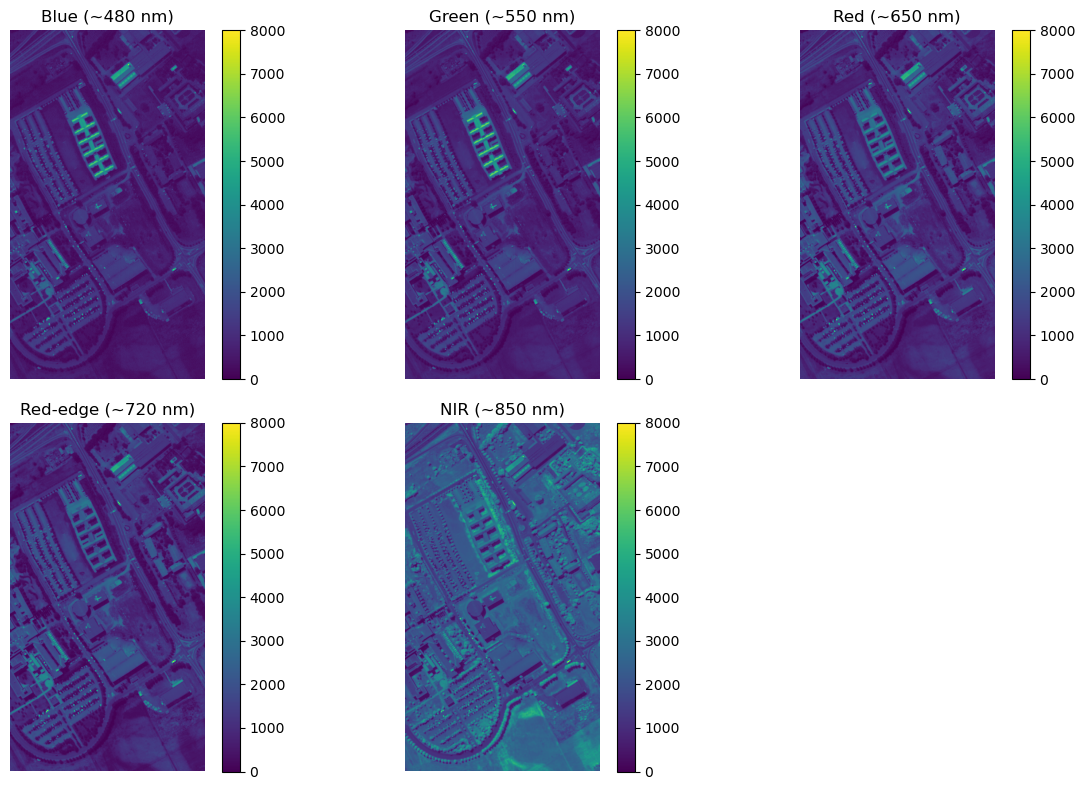

In [52]:
import matplotlib.pyplot as plt

# Extract bands
blue = paviaU[:, :, blue_band]
green = paviaU[:, :, green_band]
red = paviaU[:, :, red_band]
red_edge = paviaU[:, :, red_edge_band]
nir = paviaU[:, :, nir_band]

# Plot each band
bands = [blue, green, red, red_edge, nir]
titles = ['Blue (~480 nm)', 'Green (~550 nm)', 'Red (~650 nm)', 'Red-edge (~720 nm)', 'NIR (~850 nm)']

plt.figure(figsize=(12, 8))
for i, band in enumerate(bands):
    plt.subplot(2, 3, i + 1)
    plt.imshow(band)
    plt.colorbar()
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [46]:
# Function to display RGB image
def display_rgb_image_with_contrast_stretching(image, title='RGB Image', pmin=2, pmax=98):
    """Display RGB image from hyperspectral data."""
    blue = image[:,:,10]
    green = image[:,:,23]
    red = image[:,:,42]
    rgb_image = np.stack((red, green, blue), axis=2)

    min_val = np.percentile(rgb_image, pmin)  # Compute 2nd percentile
    max_val = np.percentile(rgb_image, pmax)  # Compute 98th percentile

    stretched = (rgb_image- min_val) / (max_val - min_val)  # Normalize
    stretched = np.clip(stretched, 0, 1)  # Clip values to [0,1] range


    # # Normalize to 0-1 range
    # rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())
    # Display the RGB image
    plt.figure(figsize=(8, 8))
    plt.imshow(stretched)
    plt.title(title)
    plt.axis('off')
    plt.show()

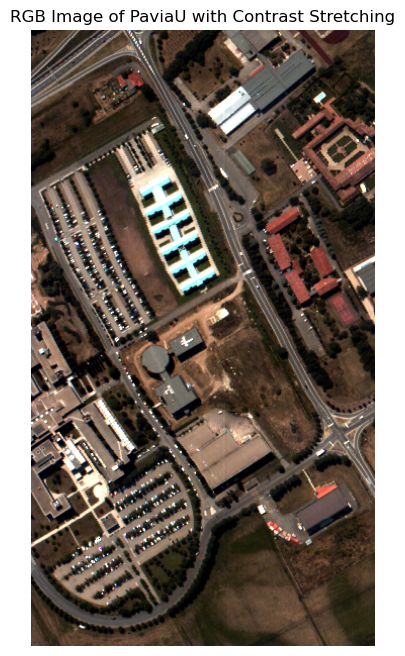

In [48]:
# Display the RGB image with contrast stretching
display_rgb_image_with_contrast_stretching(paviaU, title='RGB Image of PaviaU with Contrast Stretching')

In [53]:
#Load ground truth data
pavia_gt = loadmat('paviaU_gt.mat')
print(pavia_gt.keys())

dict_keys(['__header__', '__version__', '__globals__', 'paviaU_gt'])


In [54]:
# Extract the ground truth data
paviaU_gt = pavia_gt['paviaU_gt']

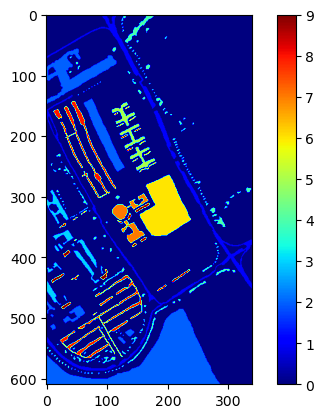

In [57]:
# Display the ground truth data
plt.imshow(paviaU_gt, cmap='jet')
plt.colorbar()